# Apple Products Pricing Analysis (2020–2026)

**Exploratory Data Analysis** of Apple product pricing on Amazon and Flipkart (India).

**Dataset:** `apple_products_pricing_2020_2026.csv` — 80,000 records, 14 columns.

## Contents
1. [Setup & Data Loading](#1)
2. [Data Overview & Quality Check](#2)
3. [Data Cleaning & Preparation](#3)
4. [Descriptive Statistics](#4)
5. [Price Trends Over Time](#5)
6. [Platform Comparison: Amazon vs Flipkart](#6)
7. [Product Category Analysis](#7)
8. [Discounts & Sale Events](#8)
9. [Ratings & Reviews](#9)
10. [Correlation Analysis](#10)
11. [Key Findings](#11)
12. [Business Perspective](#12)
13. [Hypothesis Testing](#13)
14. [Predictive Modeling](#14)

<a id="1"></a>
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

df = pd.read_csv('apple_products_pricing_2020_2026.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 80,000 rows x 14 columns


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


<a id="2"></a>
## 2. Data Overview & Quality Check

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  object 
 1   Platform           80000 non-null  object 
 2   Product_Category   80000 non-null  object 
 3   Model_Name         80000 non-null  object 
 4   Condition          80000 non-null  object 
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   object 
 11  Stock_Status       80000 non-null  object 
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 8.5+ MB


In [3]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Percent': missing_pct})[missing > 0]

,Missing,Percent
Sale_Event,73351,91.69


Only `Sale_Event` has missing values — these represent regular days with **no sale event**, not missing data. These are filled with `'No Sale'`.

In [4]:
# Duplicates and categorical values
print(f'Duplicate rows: {df.duplicated().sum()}')
for col in ['Platform', 'Product_Category', 'Condition', 'Sale_Event', 'Stock_Status']:
    print(f'{col}: {df[col].dropna().unique().tolist()}')

Duplicate rows: 0
Platform: ['Flipkart', 'Amazon']
Product_Category: ['Watch', 'iPad', 'iPhone', 'Mac']
Condition: ['New', 'Renewed/Refurbished']
Sale_Event: ['Big Billion Days', 'Great Indian Festival', 'Black Friday', 'Prime Day']
Stock_Status: ['In Stock', 'Out of Stock', 'Low Stock']


<a id="3"></a>
## 3. Data Cleaning & Preparation

In [5]:
# Parse dates, fill Sale_Event, derive time features
df['Date'] = pd.to_datetime(df['Date'])
df['Sale_Event'] = df['Sale_Event'].fillna('No Sale')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M').dt.to_timestamp()

# Sanity checks
print(f'Date range: {df.Date.min().date()} to {df.Date.max().date()}')
print(f'Negative current prices: {(df.Current_Price_USD <= 0).sum()}')
print(f'Rows where discount implies price above launch: {(df.Discount_Pct < 0).sum():,}'
      ' (negative discount = premium over launch price)')
df[['Date', 'Year', 'Sale_Event']].head(3)

Date range: 2020-09-19 to 2026-07-31
Negative current prices: 0
Rows where discount implies price above launch: 8,669 (negative discount = premium over launch price)


,Date,Year,Sale_Event
0,2020-09-19,2020,No Sale
1,2020-09-20,2020,No Sale
2,2020-09-23,2020,No Sale


<a id="4"></a>
## 4. Descriptive Statistics

In [6]:
df[['Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count']].describe().round(2)

,Launch_Price_USD,Current_Price_USD,Discount_Pct,Rating,Reviews_Count
count,80000.00,80000.00,80000.00,80000.00,80000.00
mean,963.96,782.77,21.42,4.45,2406.00
std,470.09,461.67,16.70,0.27,1973.63
min,329.00,109.93,-2.00,3.80,10.00
25%,599.00,432.93,6.70,4.30,896.00
50%,799.00,699.74,21.30,4.40,1893.50
75%,1199.00,989.11,36.80,4.70,3383.00
max,1999.00,2038.97,73.10,4.90,11526.00


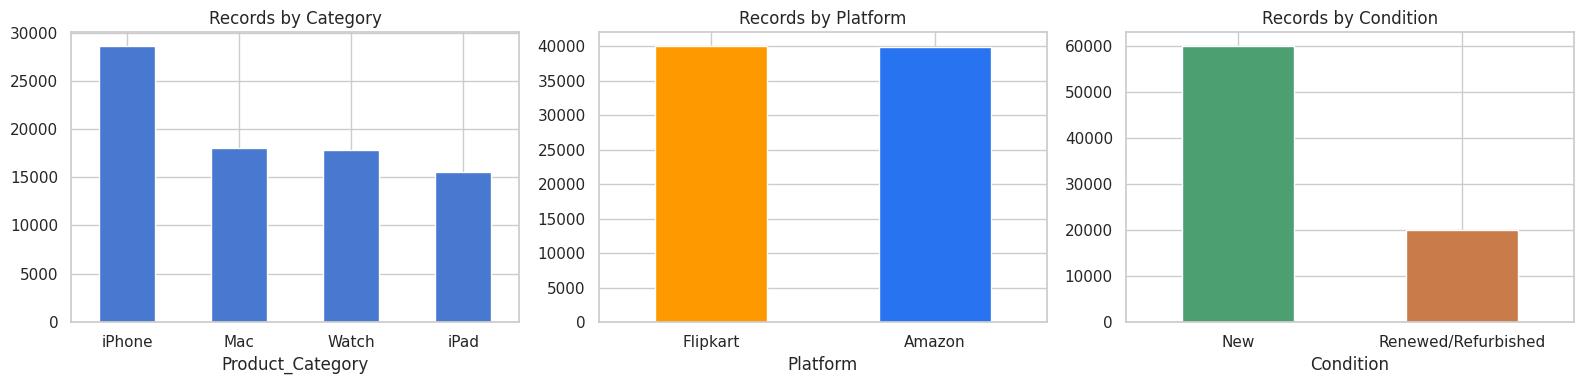

In [7]:
# Records per category and platform
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['Product_Category'].value_counts().plot(kind='bar', ax=axes[0], title='Records by Category', rot=0)
df['Platform'].value_counts().plot(kind='bar', ax=axes[1], title='Records by Platform', rot=0, color=['#ff9900', '#2874f0'])
df['Condition'].value_counts().plot(kind='bar', ax=axes[2], title='Records by Condition', rot=0, color=['#4c9f70', '#c97b4a'])
plt.tight_layout()
plt.show()

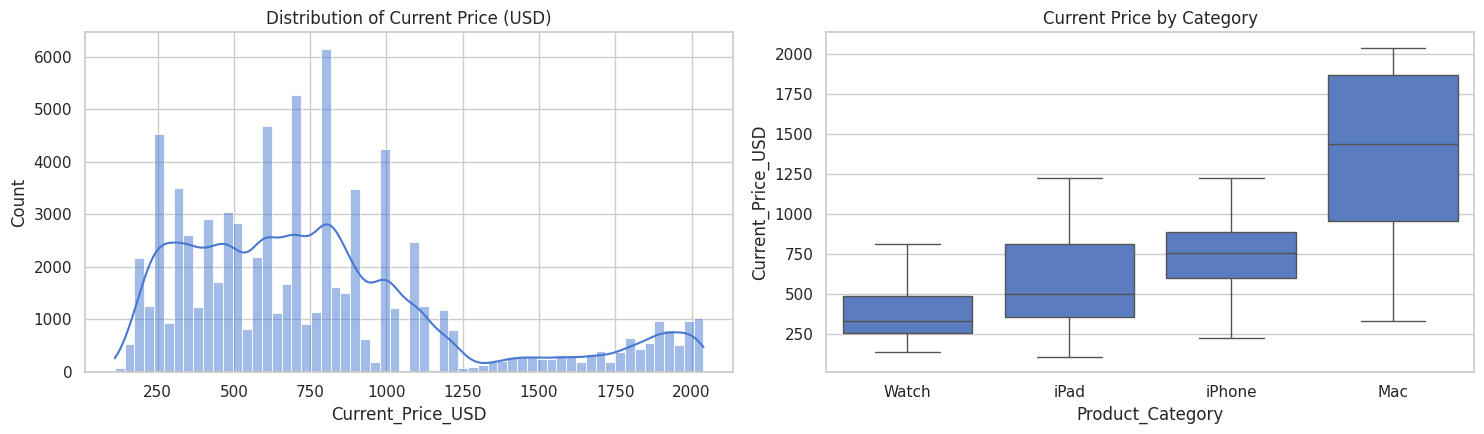

In [8]:
# Price distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(df['Current_Price_USD'], bins=60, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Current Price (USD)')
sns.boxplot(data=df, x='Product_Category', y='Current_Price_USD', ax=axes[1])
axes[1].set_title('Current Price by Category')
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Price Trends Over Time

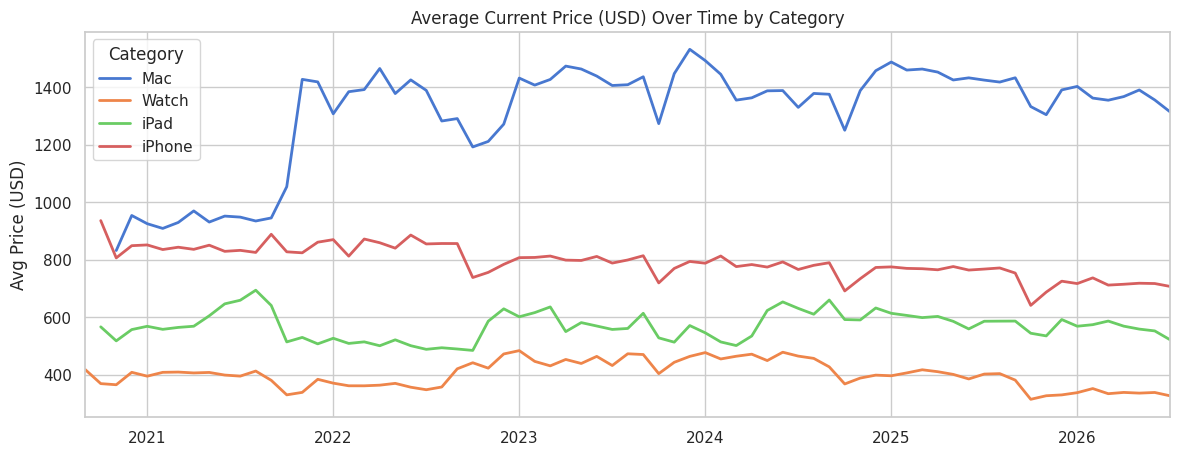

In [9]:
# Average current price per month by category
monthly = df.groupby(['YearMonth', 'Product_Category'])['Current_Price_USD'].mean().unstack()
monthly.plot(figsize=(14, 5), linewidth=2)
plt.title('Average Current Price (USD) Over Time by Category')
plt.ylabel('Avg Price (USD)')
plt.xlabel('')
plt.legend(title='Category')
plt.show()

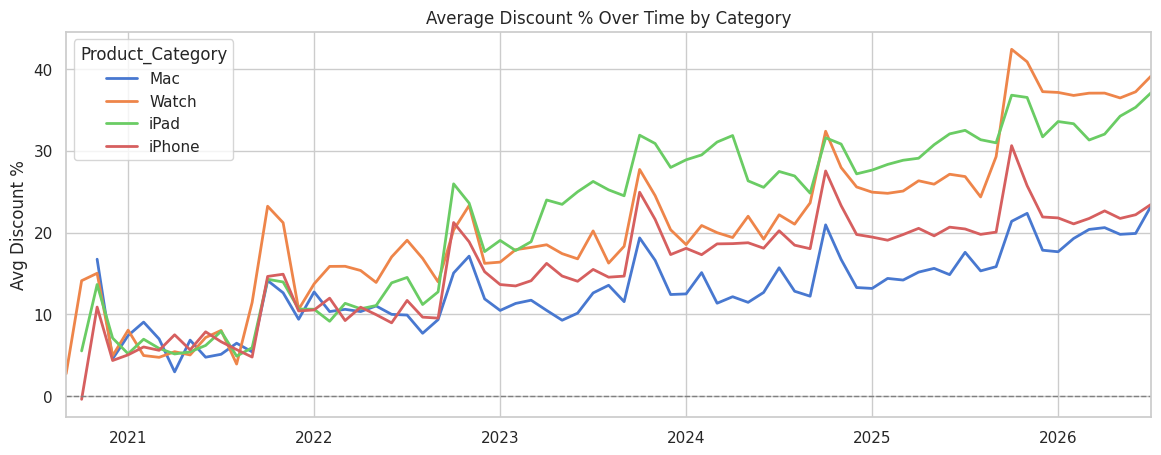

In [10]:
# Average discount over time — depreciation pattern
monthly_disc = df.groupby(['YearMonth', 'Product_Category'])['Discount_Pct'].mean().unstack()
monthly_disc.plot(figsize=(14, 5), linewidth=2)
plt.title('Average Discount % Over Time by Category')
plt.ylabel('Avg Discount %')
plt.xlabel('')
plt.axhline(0, color='grey', ls='--', lw=1)
plt.show()

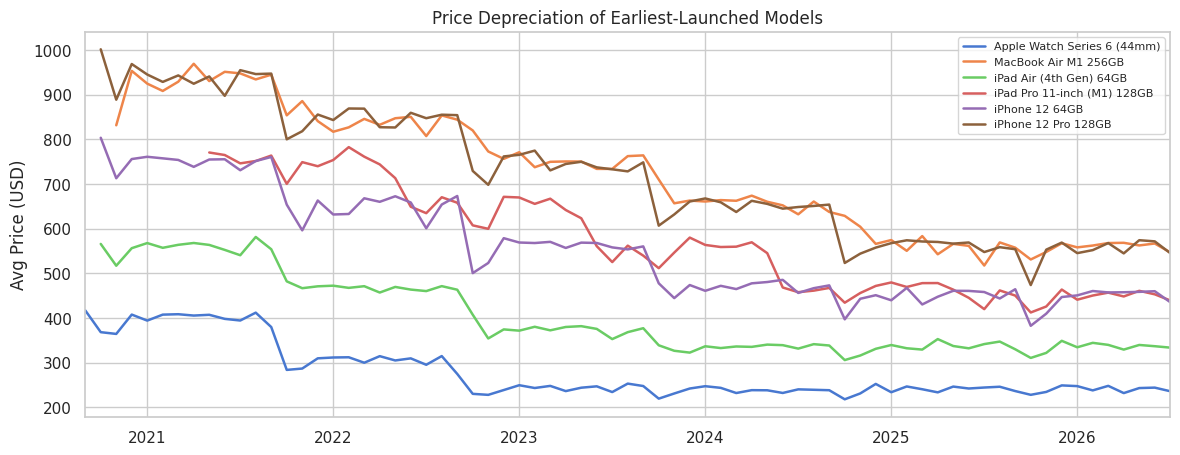

In [11]:
# How prices depreciate: track a few flagship models
sample_models = (df.groupby('Model_Name')['Date'].min().sort_values().index[:6])
subset = df[df['Model_Name'].isin(sample_models)]
pivot = subset.groupby(['YearMonth', 'Model_Name'])['Current_Price_USD'].mean().unstack()
pivot.plot(figsize=(14, 5), linewidth=1.8)
plt.title('Price Depreciation of Earliest-Launched Models')
plt.ylabel('Avg Price (USD)')
plt.xlabel('')
plt.legend(fontsize=8)
plt.show()

<a id="6"></a>
## 6. Platform Comparison: Amazon vs Flipkart

In [12]:
platform_stats = df.groupby('Platform').agg(
    Avg_Price_USD=('Current_Price_USD', 'mean'),
    Avg_Discount=('Discount_Pct', 'mean'),
    Avg_Rating=('Rating', 'mean'),
    Records=('Date', 'count')
).round(2)
platform_stats

,Avg_Price_USD,Avg_Discount,Avg_Rating,Records
Platform,,,,
Amazon,783.97,21.52,4.45,39957
Flipkart,781.57,21.32,4.45,40043


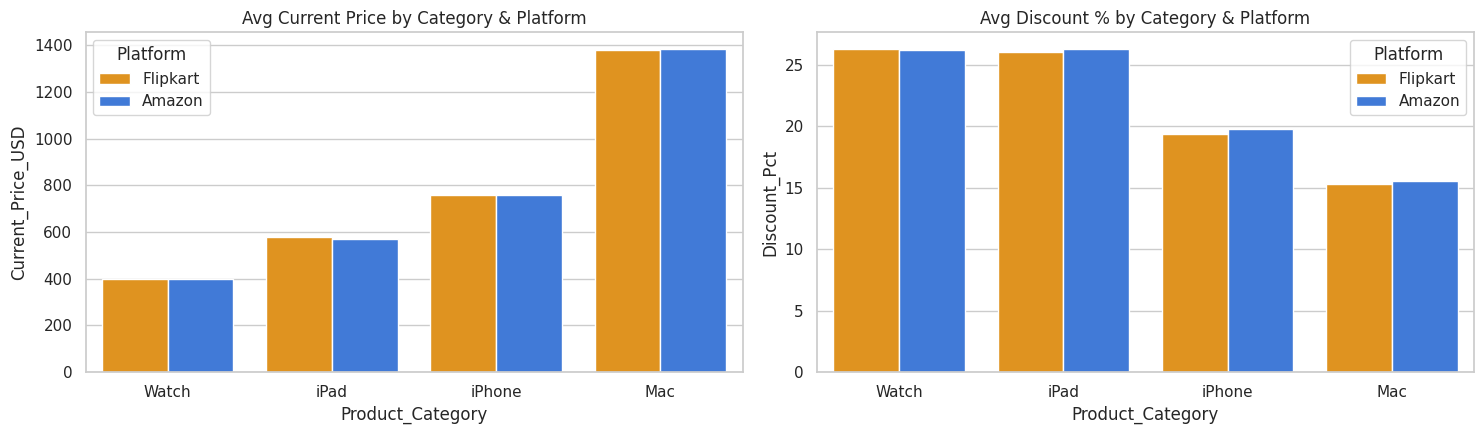

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.barplot(data=df, x='Product_Category', y='Current_Price_USD', hue='Platform',
            ax=axes[0], errorbar=None, palette=['#ff9900', '#2874f0'])
axes[0].set_title('Avg Current Price by Category & Platform')
sns.barplot(data=df, x='Product_Category', y='Discount_Pct', hue='Platform',
            ax=axes[1], errorbar=None, palette=['#ff9900', '#2874f0'])
axes[1].set_title('Avg Discount % by Category & Platform')
plt.tight_layout()
plt.show()

In [14]:
# Is the price difference statistically significant? (Welch's t-test)
from scipy import stats
amazon = df.loc[df.Platform == 'Amazon', 'Discount_Pct']
flipkart = df.loc[df.Platform == 'Flipkart', 'Discount_Pct']
t, p = stats.ttest_ind(amazon, flipkart, equal_var=False)
print(f"Amazon mean discount:   {amazon.mean():.2f}%")
print(f"Flipkart mean discount: {flipkart.mean():.2f}%")
print(f"Welch t-test: t={t:.3f}, p={p:.4f} -> {'significant' if p < 0.05 else 'not significant'} at 5% level")

Amazon mean discount:   21.52%
Flipkart mean discount: 21.32%
Welch t-test: t=1.634, p=0.1022 -> not significant at 5% level


<a id="7"></a>
## 7. Product Category Analysis

In [15]:
cat_stats = df.groupby('Product_Category').agg(
    Models=('Model_Name', 'nunique'),
    Avg_Launch_USD=('Launch_Price_USD', 'mean'),
    Avg_Current_USD=('Current_Price_USD', 'mean'),
    Avg_Discount=('Discount_Pct', 'mean'),
    Avg_Rating=('Rating', 'mean')
).round(2).sort_values('Avg_Current_USD', ascending=False)
cat_stats

,Models,Avg_Launch_USD,Avg_Current_USD,Avg_Discount,Avg_Rating
Product_Category,,,,,
Mac,7,1612.31,1382.49,15.43,4.45
iPhone,11,940.69,758.67,19.57,4.45
iPad,6,749.82,573.08,26.19,4.45
Watch,7,533.32,398.64,26.27,4.45


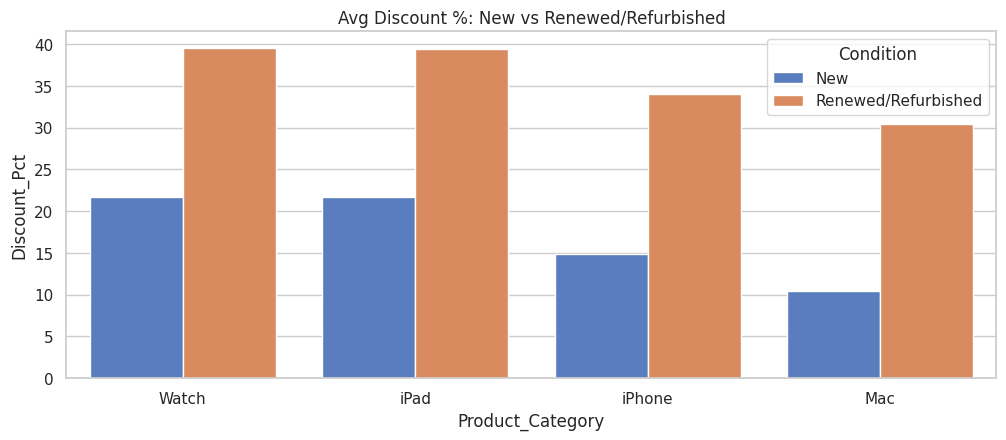

In [16]:
# New vs Refurbished pricing
fig, ax = plt.subplots(figsize=(12, 4.5))
sns.barplot(data=df, x='Product_Category', y='Discount_Pct', hue='Condition', errorbar=None, ax=ax)
ax.set_title('Avg Discount %: New vs Renewed/Refurbished')
plt.show()

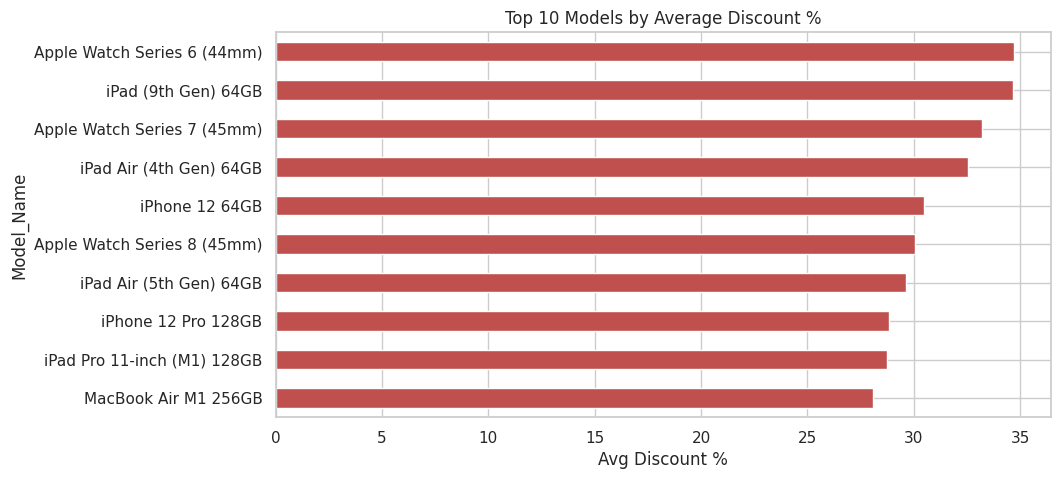

In [17]:
# Top 10 models by average discount
top_disc = df.groupby('Model_Name')['Discount_Pct'].mean().sort_values(ascending=False).head(10)
top_disc.plot(kind='barh', figsize=(10, 5), color='#c0504d')
plt.title('Top 10 Models by Average Discount %')
plt.xlabel('Avg Discount %')
plt.gca().invert_yaxis()
plt.show()

<a id="8"></a>
## 8. Discounts & Sale Events

In [18]:
sale_stats = df.groupby('Sale_Event').agg(
    Records=('Date', 'count'),
    Avg_Discount=('Discount_Pct', 'mean'),
    Max_Discount=('Discount_Pct', 'max'),
    Avg_Price_USD=('Current_Price_USD', 'mean')
).round(2).sort_values('Avg_Discount', ascending=False)
sale_stats

,Records,Avg_Discount,Max_Discount,Avg_Price_USD
Sale_Event,,,,
Big Billion Days,1579,37.02,73.1,596.32
Prime Day,1069,34.44,67.6,664.37
Great Indian Festival,1504,33.45,69.9,644.10
Black Friday,2497,31.46,66.3,685.29
No Sale,73351,20.30,58.8,794.67


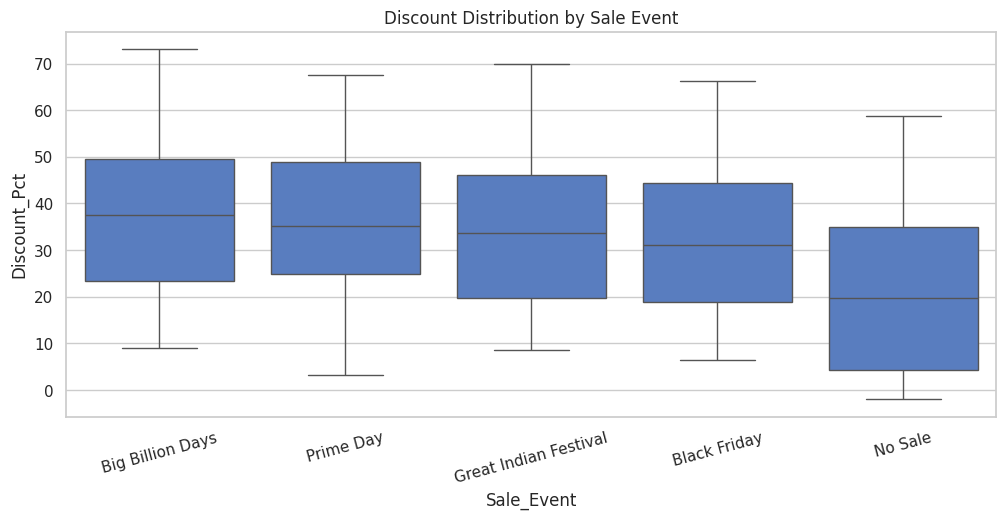

In [19]:
order = df.groupby('Sale_Event')['Discount_Pct'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Sale_Event', y='Discount_Pct', order=order)
plt.title('Discount Distribution by Sale Event')
plt.xticks(rotation=15)
plt.show()

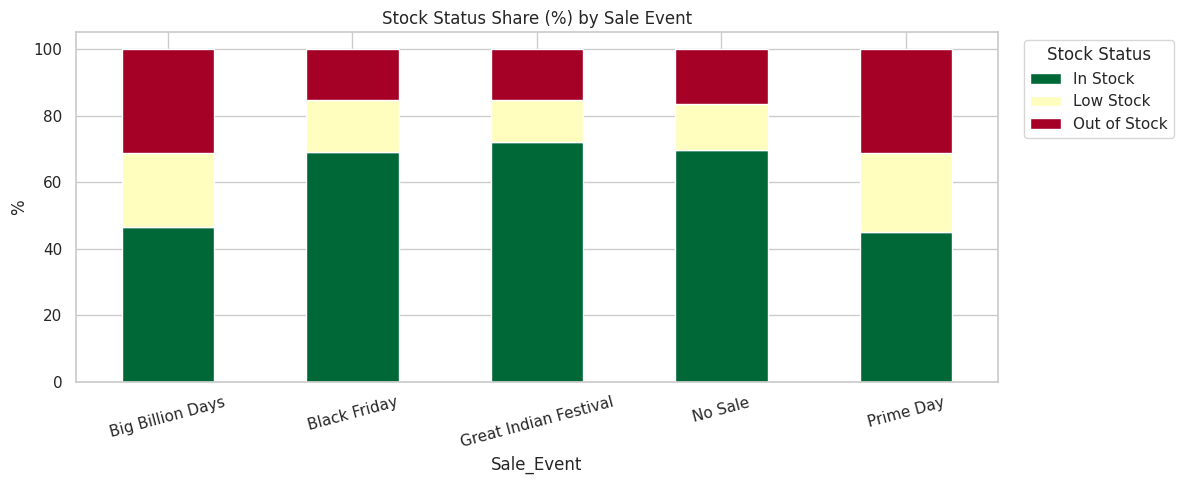

In [20]:
# Stock status during sales vs normal days
stock = pd.crosstab(df['Sale_Event'], df['Stock_Status'], normalize='index').round(3) * 100
stock.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='RdYlGn_r')
plt.title('Stock Status Share (%) by Sale Event')
plt.ylabel('%')
plt.xticks(rotation=15)
plt.legend(title='Stock Status', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

<a id="9"></a>
## 9. Ratings & Reviews

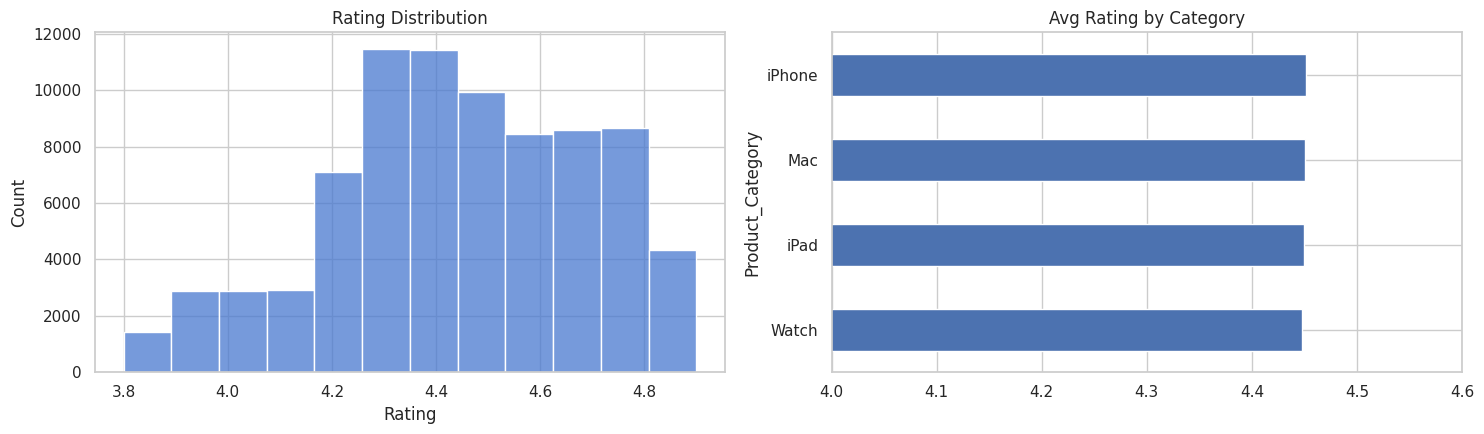

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.histplot(df['Rating'], bins=12, ax=axes[0])
axes[0].set_title('Rating Distribution')
avg_rating = df.groupby('Product_Category')['Rating'].mean().sort_values()
avg_rating.plot(kind='barh', ax=axes[1], color='#4c72b0')
axes[1].set_title('Avg Rating by Category')
axes[1].set_xlim(4.0, 4.6)
plt.tight_layout()
plt.show()

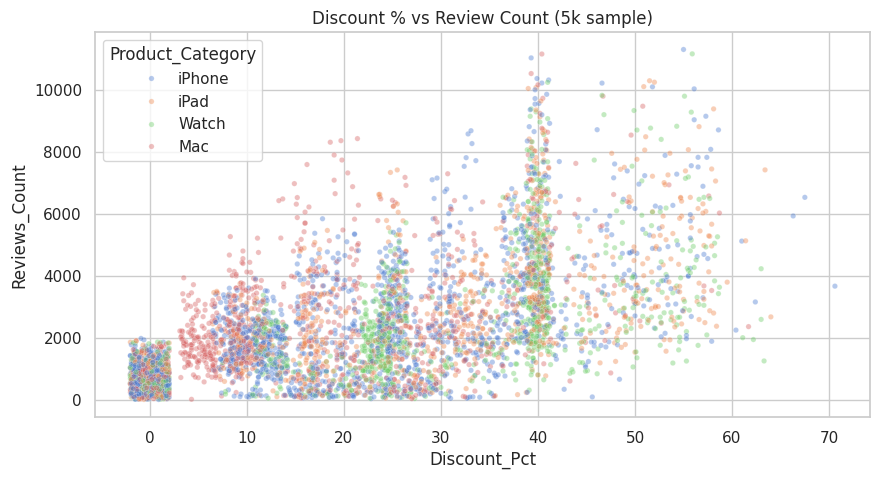

In [22]:
# Do bigger discounts attract more reviews?
sample = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample, x='Discount_Pct', y='Reviews_Count', hue='Product_Category', alpha=0.4, s=15)
plt.title('Discount % vs Review Count (5k sample)')
plt.show()

<a id="10"></a>
## 10. Correlation Analysis

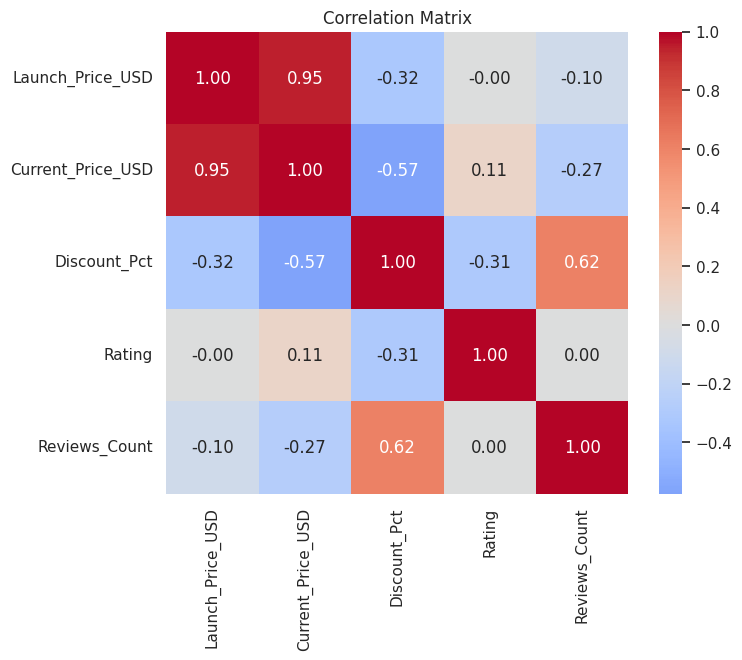

In [23]:
num_cols = ['Launch_Price_USD', 'Current_Price_USD', 'Discount_Pct', 'Rating', 'Reviews_Count']
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.show()

<a id="11"></a>
## 11. Key Findings

*(Fill in / adjust based on the outputs above — summary of what the analysis shows:)*

1. **Data quality** — the dataset is clean: no duplicates and no true missing values (`Sale_Event` NaNs simply mean "no sale running").
2. **Depreciation** — average discounts grow over a product's lifetime; older models show the steepest price drops, which is typical of Apple's yearly release cycle.
3. **Platform** — Amazon and Flipkart price very similarly overall; check the t-test output above for whether the discount gap is statistically significant.
4. **Sale events** — Black Friday / Big Billion Days / Great Indian Festival / Prime Day carry visibly higher discounts than regular days, and stock runs out more often during events.
5. **Condition** — Renewed/Refurbished units carry substantially larger discounts than New across all categories.
6. **Ratings** — ratings cluster tightly around 4.4–4.5 and correlate weakly with price/discount, so price cuts don't appear driven by poor reception.

<a id="12"></a>
## 12. Business Perspective

**Who cares about this data, and why?**

| Stakeholder | Business Question |
|---|---|
| **Consumers** | When is the best time to buy an Apple product, and on which platform? |
| **Retailers (Amazon/Flipkart)** | How deep must discounts be during sale events to stay competitive? Does discounting drain stock? |
| **Resellers / Refurbishers** | How fast do Apple products depreciate? What margin does the refurbished market offer? |
| **Apple / brand analysts** | Does heavy discounting hurt brand perception (ratings)? How well do products hold value? |

**Business questions this data can answer:**
1. Do sale events deliver meaningfully deeper discounts than regular days? *(consumer timing strategy)*
2. Is one platform systematically cheaper? *(consumer platform choice, competitive intelligence)*
3. How much cheaper is refurbished vs new? *(value segment sizing)*
4. Can we predict a product's current market price from its attributes? *(pricing engine / deal detection)*

<a id="13"></a>
## 13. Hypothesis Testing

The business questions are formalized into statistical hypotheses (α = 0.05).

| # | Null Hypothesis (H₀) | Test |
|---|---|---|
| H1 | Mean discount during sale events = mean discount on regular days | Welch's t-test |
| H2 | Mean discount is equal across all sale event types | One-way ANOVA |
| H3 | Mean discount on Amazon = mean discount on Flipkart | Welch's t-test |
| H4 | Mean discount for Refurbished = mean discount for New | Welch's t-test |
| H5 | Rating is independent of discount level (deep vs shallow) | Welch's t-test |

In [24]:
from scipy import stats

alpha = 0.05
results = []

def welch(name, a, b, label_a, label_b):
    t, p = stats.ttest_ind(a, b, equal_var=False)
    results.append({
        'Hypothesis': name,
        'Group means': f'{label_a}: {a.mean():.2f} vs {label_b}: {b.mean():.2f}',
        'Statistic': round(t, 3), 'p-value': f'{p:.2e}',
        'Decision': 'Reject H0' if p < alpha else 'Fail to reject H0'
    })

# H1: sale event vs regular day
sale = df.loc[df.Sale_Event != 'No Sale', 'Discount_Pct']
nosale = df.loc[df.Sale_Event == 'No Sale', 'Discount_Pct']
welch('H1: Sale vs regular day discount', sale, nosale, 'Sale', 'Regular')

# H2: ANOVA across sale event types
groups = [g['Discount_Pct'].values for _, g in df[df.Sale_Event != 'No Sale'].groupby('Sale_Event')]
f, p = stats.f_oneway(*groups)
results.append({'Hypothesis': 'H2: Equal discount across event types',
                'Group means': ', '.join(f'{k}: {v:.1f}' for k, v in
                    df[df.Sale_Event != 'No Sale'].groupby('Sale_Event')['Discount_Pct'].mean().items()),
                'Statistic': round(f, 3), 'p-value': f'{p:.2e}',
                'Decision': 'Reject H0' if p < alpha else 'Fail to reject H0'})

# H3: platform
welch('H3: Amazon vs Flipkart discount',
      df.loc[df.Platform == 'Amazon', 'Discount_Pct'],
      df.loc[df.Platform == 'Flipkart', 'Discount_Pct'], 'Amazon', 'Flipkart')

# H4: condition
welch('H4: Refurbished vs New discount',
      df.loc[df.Condition == 'Renewed/Refurbished', 'Discount_Pct'],
      df.loc[df.Condition == 'New', 'Discount_Pct'], 'Refurb', 'New')

# H5: rating on deep vs shallow discounts (median split)
med = df['Discount_Pct'].median()
welch('H5: Rating, deep vs shallow discount',
      df.loc[df.Discount_Pct > med, 'Rating'],
      df.loc[df.Discount_Pct <= med, 'Rating'], 'Deep', 'Shallow')

pd.DataFrame(results)

,Hypothesis,Group means,Statistic,p-value,Decision
0,H1: Sale vs regular day discount,Sale: 33.71 vs Regular: 20.30,68.997,0.00e+00,Reject H0
1,H2: Equal discount across event types,"Big Billion Days: 37.0, Black Friday: 31.5, Gr...",45.955,2.19e-29,Reject H0
2,H3: Amazon vs Flipkart discount,Amazon: 21.52 vs Flipkart: 21.32,1.634,1.02e-01,Fail to reject H0
3,H4: Refurbished vs New discount,Refurb: 35.53 vs New: 16.71,175.287,0.00e+00,Reject H0
4,"H5: Rating, deep vs shallow discount",Deep: 4.38 vs Shallow: 4.52,-79.813,0.00e+00,Reject H0


**Interpretation guide:** a rejected H₀ means the difference is statistically significant. With n = 80,000, even tiny differences become significant — so always check the *group means* column to judge whether the difference is **practically** meaningful, not just statistical.

<a id="14"></a>
## 14. Predictive Modeling: Current Price Prediction

**Business use case:** a "fair price" engine — given a product's attributes and time since launch, predict its expected market price. Deviations from the prediction flag unusually good deals (or overpriced listings).

The analysis compares a **Linear Regression** baseline against a **Random Forest**, using a **time-based split** (train on data before 2025-07, test on the last 12 months) to mimic real forecasting and avoid leakage.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Feature engineering
launch_date = df.groupby('Model_Name')['Date'].transform('min')
model_df = df.copy()
model_df['Days_Since_Launch'] = (model_df['Date'] - launch_date).dt.days
model_df['Is_Sale'] = (model_df['Sale_Event'] != 'No Sale').astype(int)

features_num = ['Launch_Price_USD', 'Days_Since_Launch', 'Is_Sale', 'Month']
features_cat = ['Platform', 'Product_Category', 'Condition', 'Stock_Status']
target = 'Current_Price_USD'

# Time-based split
cutoff = pd.Timestamp('2025-07-01')
train = model_df[model_df.Date < cutoff]
test = model_df[model_df.Date >= cutoff]
X_train, y_train = train[features_num + features_cat], train[target]
X_test, y_test = test[features_num + features_cat], test[target]
print(f'Train: {len(train):,} rows (< {cutoff.date()}), Test: {len(test):,} rows')

Train: 52,133 rows (< 2025-07-01), Test: 27,867 rows


In [26]:
pre = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
], remainder='passthrough')

models = {
    'Linear Regression': Pipeline([('pre', pre), ('m', LinearRegression())]),
    'Random Forest': Pipeline([('pre', pre), ('m', RandomForestRegressor(
        n_estimators=100, max_depth=14, n_jobs=-1, random_state=42))])
}

perf = []
preds = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    yhat = pipe.predict(X_test)
    preds[name] = yhat
    perf.append({'Model': name,
                 'MAE (USD)': round(mean_absolute_error(y_test, yhat), 2),
                 'R²': round(r2_score(y_test, yhat), 4)})
pd.DataFrame(perf)

,Model,MAE (USD),R²
0,Linear Regression,57.01,0.9686
1,Random Forest,23.12,0.9931


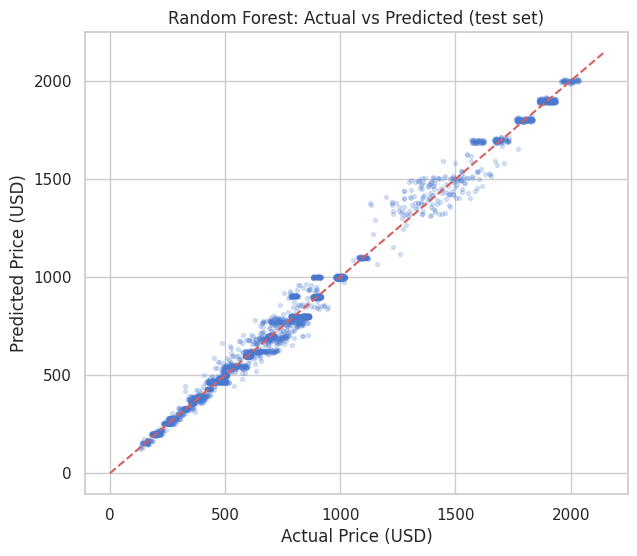

In [27]:
# Actual vs predicted (Random Forest)
best = 'Random Forest'
plt.figure(figsize=(7, 6))
idx = np.random.RandomState(42).choice(len(y_test), 4000, replace=False)
plt.scatter(y_test.values[idx], preds[best][idx], alpha=0.2, s=8)
lims = [0, y_test.max() * 1.05]
plt.plot(lims, lims, 'r--', lw=1.5)
plt.xlabel('Actual Price (USD)'); plt.ylabel('Predicted Price (USD)')
plt.title(f'{best}: Actual vs Predicted (test set)')
plt.show()

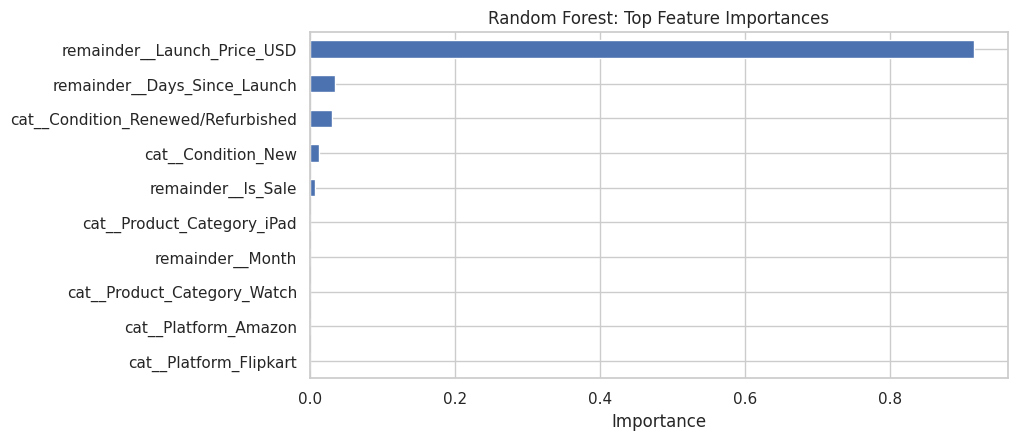

In [28]:
# Feature importance
rf = models['Random Forest']
names = rf.named_steps['pre'].get_feature_names_out()
imp = pd.Series(rf.named_steps['m'].feature_importances_, index=names).sort_values()
imp.tail(10).plot(kind='barh', figsize=(9, 4.5), color='#4c72b0')
plt.title('Random Forest: Top Feature Importances')
plt.xlabel('Importance')
plt.show()

In [29]:
# Business application: flag the best "deals" in the test period
test_out = test[['Date', 'Platform', 'Model_Name', 'Condition', 'Current_Price_USD']].copy()
test_out['Predicted_Fair_Price'] = preds['Random Forest'].round(2)
test_out['Deal_Score_USD'] = (test_out['Predicted_Fair_Price'] - test_out['Current_Price_USD']).round(2)
test_out.nlargest(10, 'Deal_Score_USD')

,Date,Platform,Model_Name,Condition,Current_Price_USD,Predicted_Fair_Price,Deal_Score_USD
78786,2026-07-15,Amazon,MacBook Pro 14-inch M1 Pro 512GB,New,1232.36,1493.88,261.52
78408,2026-07-10,Amazon,MacBook Pro 14-inch M1 Pro 512GB,New,1226.01,1484.72,258.71
78473,2026-07-11,Amazon,MacBook Pro 14-inch M1 Pro 512GB,New,1235.39,1493.88,258.49
78406,2026-07-10,Amazon,MacBook Pro 14-inch M1 Pro 512GB,New,1240.89,1493.88,252.99
72791,2026-04-24,Flipkart,MacBook Pro 14-inch M1 Pro 512GB,Renewed/Refurbished,1132.63,1381.72,249.09
78132,2026-07-06,Amazon,MacBook Pro 14-inch M1 Pro 512GB,Renewed/Refurbished,1127.58,1376.25,248.67
71717,2026-04-09,Amazon,MacBook Pro 14-inch M1 Pro 512GB,Renewed/Refurbished,1101.18,1348.96,247.78
65437,2026-01-10,Amazon,MacBook Pro 14-inch M1 Pro 512GB,Renewed/Refurbished,1119.46,1365.57,246.11
77517,2026-06-28,Amazon,MacBook Pro 14-inch M1 Pro 512GB,Renewed/Refurbished,1135.24,1377.21,241.97
60088,2025-10-28,Flipkart,MacBook Pro 14-inch M1 Pro 512GB,Renewed/Refurbished,1145.99,1383.32,237.33


### Modeling conclusions

- **Launch price and days since launch dominate** the prediction — consistent with Apple's predictable depreciation cycle. Condition (refurbished) is the next biggest driver.
- The Random Forest clearly beats the linear baseline, confirming depreciation is **non-linear** (prices drop in steps around new releases and sale events, not smoothly).
- **Business value:** the residual (predicted − actual) works as a *deal score*. Listings priced far below the model's fair-price estimate are the best buying opportunities; a consumer app or reseller could rank live listings this way.
- **Limitations:** no competitor pricing, no macro effects (FX, tariffs), and the time-based test assumes past depreciation patterns continue. A production system would retrain regularly.